# House Price Prediction — Train & Predict

Một notebook duy nhất: load dữ liệu từ Supabase → xem dữ liệu training → train model → đánh giá → dự đoán giá cho toàn bộ listings.

> **Kernel:** chọn `Python (HousePricePrediction .venv)` rồi chạy các cell từ trên xuống dưới.

## 0. Setup

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import pickle

sys.path.insert(0, str(Path.cwd().parent))
from pipeline.supabase_handler import fetch_csv_from_supabase

print("✅ Imports successful")

✅ Imports successful


## Part 1 — Training

### 1.1 Load dữ liệu từ Supabase

In [2]:
df = fetch_csv_from_supabase("Raw_Features")

# Convert price from VND to billion VND
df['price_billion_vnd'] = df['price_vnd'] / 1e9

print(f"✓ Loaded {len(df)} records, {len(df.columns)} columns")
print(f"Price range: {df['price_billion_vnd'].min():.2f} – {df['price_billion_vnd'].max():.2f} billion VND")

# Save a snapshot of the raw data
data_dir = Path('data')
data_dir.mkdir(exist_ok=True)
df.to_csv(data_dir / 'raw_data.csv', index=False)
print("✓ Saved snapshot: data/raw_data.csv")

df.head(10)

📖 Fetching data from Supabase table: Raw_Features


✓ Fetched 8581 rows from Raw_Features

✓ Loaded 8581 records, 45 columns
Price range: 0.00 – 2100.00 billion VND


✓ Saved snapshot: data/raw_data.csv


,link,title,post_day,street,old_address,locality,region,listing_id,direction,listing_type,...,marketplace_count_3km,nearest_supermarket_km,supermarket_count_3km,nearest_mall_km,mall_count_3km,nearest_bus_stop_km,bus_stop_count_1km,nearest_metro_km,metro_count_5km,price_billion_vnd
0,https://alonhadat.com.vn/ban-nha-rieng-hem-xe-...,Bán nhà riêng hẻm xe hơi 4 tầng mới đẹp lung l...,2026-05-23,đường lê quang định,"Đường Lê Quang Định, Phường 14, Quận Bình Thạn...",phường bình thạnh,hồ chí minh,18269430,unknown,can_ban,...,16,0.127429,61,3.067850,0,0.108269,47,2.080087,7,8.90
1,https://alonhadat.com.vn/sieu-vi-tri-toa-nha-h...,SIÊU VỊ TRÍ TÒA NHÀ HẦM 10 TẦNG LÊ THÁNH TÔN-Q...,2026-05-27,đường lê thánh tôn,"Đường Lê Thánh Tôn, Phường Bến Nghé, Quận 1, H...",phường sài gòn,hồ chí minh,17891053,unknown,can_ban,...,22,0.331273,97,0.690744,15,0.089534,68,0.352320,7,110.00
2,https://alonhadat.com.vn/ban-gap-nha-4-tang-ng...,"BÁN GẤP NHÀ 4 TẦNG NGANG KHỦNG 4,8M – TRẦN QUA...",2026-06-30,đường trần quang diệu,"Đường Trần Quang Diệu, Phường 14, Quận 3, Hồ C...",phường nhiêu lộc,hồ chí minh,18843030,unknown,can_ban,...,47,0.293004,108,0.833065,16,0.144080,55,2.531594,4,7.99
3,https://alonhadat.com.vn/4x11-nha-co-2-lau-moi...,"4x11, nhà có 2 lầu mới đường số 3, giáp Thạch LAM",2026-06-30,đường số 3,"Đường Số 3, Phường Bình Hưng Hòa A, Quận Bình ...",phường bình hưng hòa,hồ chí minh,18614772,unknown,can_ban,...,2,1.674035,14,1.509740,1,0.521155,15,NaN,0,4.35
4,https://alonhadat.com.vn/ban-biet-thu-khu-comp...,Bán Biệt Thự Khu Compound 284 Nguyễn Trọng Tuy...,2026-05-27,đường nguyễn trọng tuyển,"Đường Nguyễn Trọng Tuyển, Phường 10, Quận Phú ...",phường phú nhuận,hồ chí minh,16693368,unknown,can_ban,...,19,0.256364,53,1.945490,6,0.155312,47,3.900285,4,45.00
5,https://alonhadat.com.vn/thanh-ly-can-nha-cap-...,Thanh lý căn nhà 1 trệt 1 lầu TP.HCM bán trả nợ,2026-06-10,đường bình hưng,"Đường Bình Hưng, Xã Bình Hưng, Huyện Bình Chán...",xã bình hưng,hồ chí minh,18767045,unknown,can_ban,...,9,1.922488,5,1.961150,3,0.154980,18,NaN,0,1.05
6,https://alonhadat.com.vn/4x14-nha-duc-4-tam-kh...,"4x14, nhà đúc 4 tấm, khu Lê văn Quới vào, đườn...",2026-06-30,đường số 14,"Đường Số 14, Phường Bình Hưng Hòa A, Quận Bình...",phường bình hưng hòa,hồ chí minh,18835058,unknown,can_ban,...,13,0.555815,26,2.498830,1,0.400331,11,NaN,0,5.38
7,https://alonhadat.com.vn/-hem-xe-hoi-7m-4-tang...,🏡 HÀNG HIẾM BÌNH THẠNH - CHỈ NHÚ 7 TỶ SỞ HỮU H...,2026-06-30,đường bình lợi,"Đường Bình Lợi, Phường 13, Quận Bình Thạnh, Hồ...",phường bình lợi trung,hồ chí minh,18826870,unknown,can_ban,...,12,0.726789,44,1.764600,7,0.160326,39,3.402818,5,7.30
8,https://alonhadat.com.vn/nha-moi-chu-gui-ban-l...,"NHÀ MỚI CHỦ GỬI BÁN LẠI GIÁ 1TỶ950TR SỔ RIÊNG,...",2026-07-01,đường dương đình cúc,"Đường Dương Đình Cúc, Xã Tân Kiên, Huyện Bình ...",xã tân nhựt,hồ chí minh,18854782,unknown,can_ban,...,11,1.840131,3,NaN,0,0.008888,29,NaN,0,1.95
9,https://alonhadat.com.vn/ban-nha-mat-tien-duon...,Bán nhà mặt tiền đường số 2 khu The Vista An P...,2026-07-01,đường số 2,"Đường Số 2, Phường An Khánh, Thành phố Thủ Đức...",phường an khánh,hồ chí minh,18854229,unknown,can_ban,...,9,0.559203,26,0.968627,6,0.217555,12,1.038473,8,45.00


### 1.2 Features & target

In [3]:
# Numeric features (geospatial + property)
NUMERIC_COLS = [
    'nearest_school_km', 'school_count_3km',
    'nearest_hospital_km', 'hospital_count_5km',
    'nearest_marketplace_km', 'marketplace_count_3km',
    'nearest_supermarket_km', 'supermarket_count_3km',
    'nearest_mall_km', 'mall_count_3km',
    'nearest_bus_stop_km', 'bus_stop_count_1km',
    'nearest_metro_km', 'metro_count_5km',
    'area_m2', 'distance_to_center_km',
    'num_floors', 'num_bedrooms', 'road_width_m', 'width_m', 'length_m',
    'locality_population_density'
]

# Binary features (True/False → 0/1)
BIN_COLS = [
    'dining_room_bin', 'kitchen_bin', 'terrace_bin',
    'car_parking_bin', 'owner_listing_bin'
]

# Text features → one-hot encode
CAT_COLS = ['property_type', 'legal_status', 'direction']

# Dropped: locality, region, locality_square (location identifiers),
# listing_type (single value), link/title/street/addresses (free text), lat/lon
TARGET_COL = 'price_billion_vnd'

print(f"{len(NUMERIC_COLS)} numeric + {len(BIN_COLS)} binary + {len(CAT_COLS)} categorical, target = {TARGET_COL}")

22 numeric + 5 binary + 3 categorical, target = price_billion_vnd


### 1.3 Khám phá dữ liệu training

Thống kê mô tả và tỉ lệ thiếu dữ liệu của các cột dùng để train.

In [4]:
# Descriptive statistics of numeric features + target
df[NUMERIC_COLS + [TARGET_COL]].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
nearest_school_km,8578.0,0.32,0.31,0.00,0.14,0.24,0.42,4.91
school_count_3km,8581.0,102.35,59.25,0.00,56.00,93.00,150.00,226.00
nearest_hospital_km,8558.0,1.02,0.87,0.00,0.38,0.76,1.42,5.00
hospital_count_5km,8581.0,42.59,30.69,0.00,12.00,39.00,76.00,92.00
nearest_marketplace_km,8560.0,0.67,0.55,0.00,0.34,0.51,0.86,4.49
marketplace_count_3km,8581.0,20.27,15.74,0.00,8.00,16.00,32.00,61.00
nearest_supermarket_km,8452.0,0.67,0.62,0.00,0.25,0.49,0.88,4.93
supermarket_count_3km,8581.0,39.19,33.08,0.00,11.00,28.00,61.00,117.00
nearest_mall_km,8097.0,1.71,1.09,0.03,0.80,1.53,2.29,5.07
mall_count_3km,8581.0,5.98,5.90,0.00,1.00,4.00,9.00,21.00


In [5]:
# Missing values per training column
cols = NUMERIC_COLS + BIN_COLS + CAT_COLS + [TARGET_COL]
missing = df[cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_table = pd.DataFrame({'missing': missing, 'missing_%': missing_pct})
missing_table[missing_table['missing'] > 0].sort_values('missing', ascending=False)

,missing,missing_%
nearest_metro_km,3673,42.8
length_m,1096,12.8
width_m,805,9.4
nearest_mall_km,484,5.6
num_floors,184,2.1
nearest_supermarket_km,129,1.5
num_bedrooms,125,1.5
nearest_hospital_km,23,0.3
nearest_marketplace_km,21,0.2
road_width_m,21,0.2


In [6]:
# Binary & categorical features overview
for col in BIN_COLS:
    counts = df[col].value_counts()
    print(f"{col:22s} True: {counts.get(True, 0):>5} | False: {counts.get(False, 0):>5}")

for col in CAT_COLS:
    print(f"\n{col}:")
    print(df[col].fillna('(missing)').value_counts().to_string())

dining_room_bin        True:  3740 | False:  4841
kitchen_bin            True:  3793 | False:  4788
terrace_bin            True:  2963 | False:  5618
car_parking_bin        True:  3086 | False:  5495
owner_listing_bin      True:     3 | False:  8578

property_type:
property_type
nha_mat_tien     4356
nha_trong_hem    4225

legal_status:
legal_status
so_hong_so_do     5818
unknown           2420
giay_to_hop_le     343

direction:
direction
unknown     7912
dong_nam     196
tay_bac       91
tay_nam       86
dong_bac      68
dong          67
bac           56
tay           55
nam           50


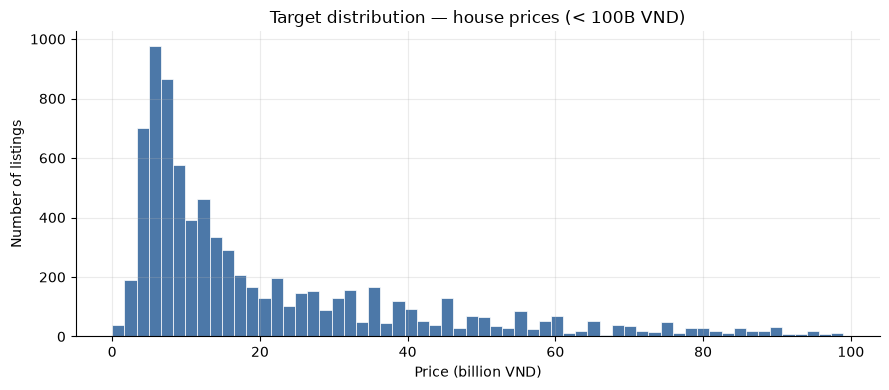

Median price: 13.50 billion VND


In [7]:
# Distribution of the target (house prices)
prices = df[TARGET_COL].dropna()
prices_plot = prices[prices < 100]  # same outlier cutoff as training

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(prices_plot, bins=60, color='#4C78A8', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Price (billion VND)')
ax.set_ylabel('Number of listings')
ax.set_title('Target distribution — house prices (< 100B VND)')
ax.grid(True, alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Median price: {prices.median():.2f} billion VND")

### 1.4 Chuẩn bị dữ liệu

Bỏ dòng thiếu giá, điền median cho feature số bị thiếu, chuyển bin → 0/1, one-hot các cột chữ, loại outlier (giá > 100 tỷ).

In [8]:
df_clean = df.dropna(subset=[TARGET_COL]).copy()
print(f"After dropping NaN prices: {len(df_clean)} records")

# Numeric: fill missing with column medians
X_num = df_clean[NUMERIC_COLS].fillna(df_clean[NUMERIC_COLS].median())

# Binary: True/False → 1/0
X_bin = df_clean[BIN_COLS].astype(int)

# Categorical text → one-hot (missing → 'unknown')
X_cat = pd.get_dummies(df_clean[CAT_COLS].fillna('unknown')).astype(int)

X = pd.concat([X_num, X_bin, X_cat], axis=1)
FEATURE_COLS = list(X.columns)
y = df_clean[TARGET_COL].copy()

# Remove outliers (price > 100B VND)
mask = y < 100
X, y = X[mask], y[mask]
print(f"✓ Ready for training: X={X.shape} ({len(FEATURE_COLS)} features), y={y.shape}")

# Save the model-ready dataset (features + target)
ready = X.copy()
ready[TARGET_COL] = y
ready.to_csv(data_dir / 'model_ready_data.csv', index=False)
print("✓ Saved: data/model_ready_data.csv")

# The actual training data fed to the models:
X.head(10)

After dropping NaN prices: 8580 records
✓ Ready for training: X=(7943, 41) (41 features), y=(7943,)


✓ Saved: data/model_ready_data.csv


,nearest_school_km,school_count_3km,nearest_hospital_km,hospital_count_5km,nearest_marketplace_km,marketplace_count_3km,nearest_supermarket_km,supermarket_count_3km,nearest_mall_km,mall_count_3km,...,legal_status_unknown,direction_bac,direction_dong,direction_dong_bac,direction_dong_nam,direction_nam,direction_tay,direction_tay_bac,direction_tay_nam,direction_unknown
0,0.153656,117,0.325367,47,0.317341,16,0.127429,61,3.067850,0,...,1,0,0,0,0,0,0,0,0,1
2,0.229839,205,0.440702,85,0.351894,47,0.293004,108,0.833065,16,...,0,0,0,0,0,0,0,0,0,1
3,0.195349,63,1.131729,7,1.901845,2,1.674035,14,1.509740,1,...,0,0,0,0,0,0,0,0,0,1
4,0.428857,154,0.311812,76,0.571107,19,0.256364,53,1.945490,6,...,1,0,0,0,0,0,0,0,0,1
5,0.644832,43,0.238080,37,2.021535,9,1.922488,5,1.961150,3,...,0,0,0,0,0,0,0,0,0,1
6,0.795336,62,1.559184,17,0.622772,13,0.555815,26,2.498830,1,...,0,0,0,0,0,0,0,0,0,1
7,0.456568,100,0.964865,45,0.427097,12,0.726789,44,1.764600,7,...,0,0,0,0,0,0,0,0,0,1
8,0.052544,12,0.742491,3,1.060617,11,1.840131,3,1.533980,0,...,0,0,0,0,0,0,0,0,0,1
9,0.262958,53,0.254743,14,0.629161,9,0.559203,26,0.968627,6,...,0,0,0,0,0,0,0,0,0,1
12,0.095571,206,0.115089,81,0.628283,52,0.425214,51,0.399301,11,...,0,0,0,0,0,0,0,0,0,1


### 1.5 Chia train / test (80–20)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)} samples | Test: {len(X_test)} samples")

Train: 6354 samples | Test: 1589 samples


### 1.6 Train models

In [10]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
print(f"Random Forest      R²: {rf_r2:.4f} | RMSE: {rf_rmse:.4f} | MAE: {rf_mae:.4f} (billion VND)")

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)
gb_r2 = r2_score(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_mae = mean_absolute_error(y_test, gb_pred)
print(f"Gradient Boosting  R²: {gb_r2:.4f} | RMSE: {gb_rmse:.4f} | MAE: {gb_mae:.4f} (billion VND)")

Random Forest      R²: 0.8317 | RMSE: 8.3306 | MAE: 4.7298 (billion VND)


Gradient Boosting  R²: 0.8210 | RMSE: 8.5915 | MAE: 5.2001 (billion VND)


### 1.7 So sánh & chọn model tốt nhất

In [11]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting'],
    'R²': [rf_r2, gb_r2],
    'RMSE (billion VND)': [rf_rmse, gb_rmse],
    'MAE (billion VND)': [rf_mae, gb_mae],
}).round(4)

best_name = 'random_forest' if rf_r2 > gb_r2 else 'gradient_boosting'
best_model = rf if rf_r2 > gb_r2 else gb
best_r2 = max(rf_r2, gb_r2)
print(f"✅ Best model: {best_name.upper()} (R² = {best_r2:.4f})")

comparison

✅ Best model: RANDOM_FOREST (R² = 0.8317)


,Model,R²,RMSE (billion VND),MAE (billion VND)
0,Random Forest,0.8317,8.3306,4.7298
1,Gradient Boosting,0.8210,8.5915,5.2001


### 1.8 Đánh giá model tốt nhất

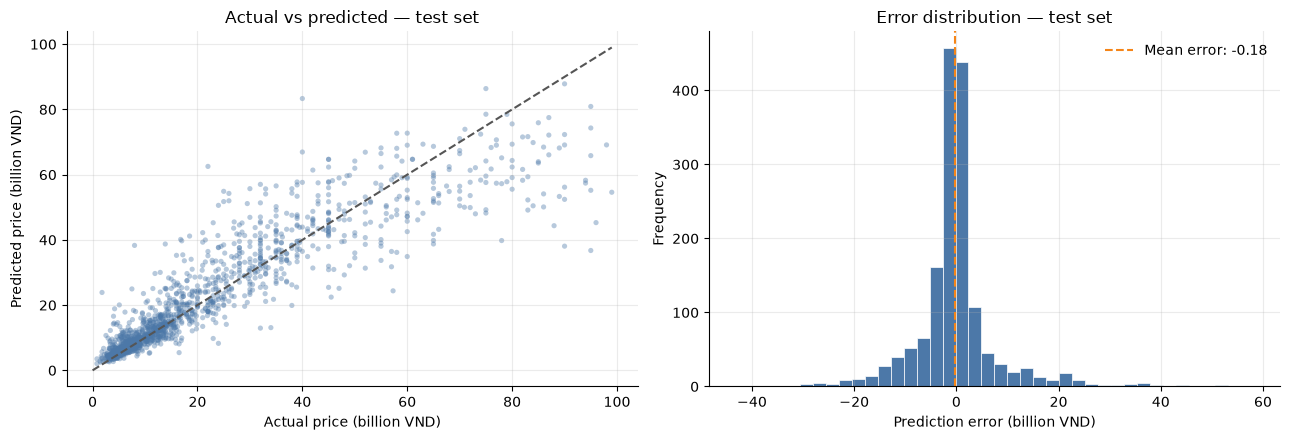

In [12]:
y_best_pred = best_model.predict(X_test)
errors = y_test - y_best_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Actual vs predicted (test set)
axes[0].scatter(y_test, y_best_pred, s=14, alpha=0.4, color='#4C78A8', edgecolors='none')
lims = [0, max(y_test.max(), y_best_pred.max())]
axes[0].plot(lims, lims, '--', color='#555555', lw=1.5)
axes[0].set_xlabel('Actual price (billion VND)')
axes[0].set_ylabel('Predicted price (billion VND)')
axes[0].set_title('Actual vs predicted — test set')
axes[0].grid(True, alpha=0.25)
axes[0].spines[['top', 'right']].set_visible(False)

# Error distribution
axes[1].hist(errors, bins=40, color='#4C78A8', edgecolor='white', linewidth=0.5)
axes[1].axvline(errors.mean(), color='#F58518', linestyle='--', lw=1.5,
                label=f'Mean error: {errors.mean():.2f}')
axes[1].set_xlabel('Prediction error (billion VND)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Error distribution — test set')
axes[1].legend(frameon=False)
axes[1].grid(True, alpha=0.25)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### 1.9 Feature importance

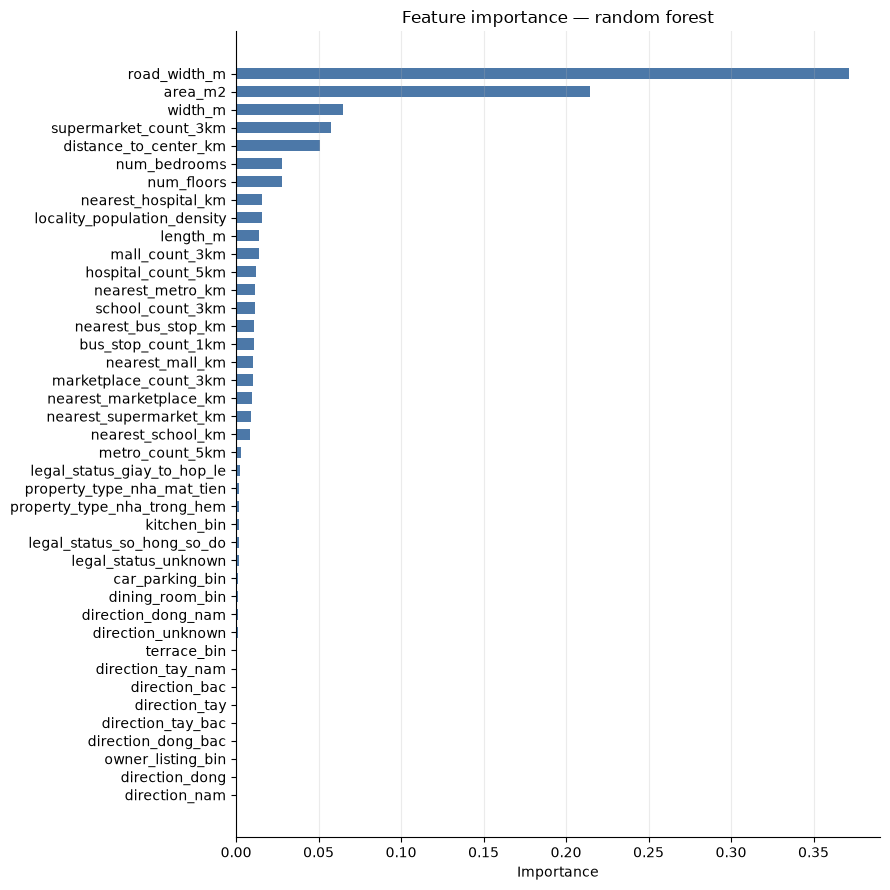

In [13]:
importance = (
    pd.Series(best_model.feature_importances_, index=FEATURE_COLS)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(importance.index, importance.values, height=0.62, color='#4C78A8')
ax.set_xlabel('Importance')
ax.set_title(f'Feature importance — {best_name.replace("_", " ")}')
ax.grid(True, axis='x', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 1.10 Lưu model

In [14]:
model_dir = Path('saved_models')
model_dir.mkdir(exist_ok=True)

model_path = model_dir / f"{best_name}.joblib"
joblib.dump(best_model, model_path)
print(f"✓ Saved model: {model_path}")

metadata = {
    'model_type': best_name,
    'features': FEATURE_COLS,
    'metrics': {
        'r2_score': float(best_r2),
        'rmse': float(np.sqrt(mean_squared_error(y_test, y_best_pred))),
        'mae': float(mean_absolute_error(y_test, y_best_pred)),
    },
    'train_size': len(X_train),
    'test_size': len(X_test),
}
meta_path = model_dir / f"{best_name}_meta.pkl"
with open(meta_path, 'wb') as f:
    pickle.dump(metadata, f)
print(f"✓ Saved metadata: {meta_path}")

✓ Saved model: saved_models\random_forest.joblib
✓ Saved metadata: saved_models\random_forest_meta.pkl


## Part 2 — Inference

Load model đã lưu và dự đoán giá cho **toàn bộ** listings (dùng `df` đã load ở Part 1).

### 2.1 Load model đã lưu

In [15]:
model_dir = Path('saved_models')
model_files = sorted(model_dir.glob('*.joblib'))
assert model_files, "No trained models found — run Part 1 first"

latest_model = model_files[-1]
model = joblib.load(latest_model)

with open(model_dir / f"{latest_model.stem}_meta.pkl", 'rb') as f:
    metadata = pickle.load(f)

print(f"✓ Loaded {metadata['model_type']}")
print(f"  R²: {metadata['metrics']['r2_score']:.4f} | RMSE: {metadata['metrics']['rmse']:.4f} billion VND")

✓ Loaded random_forest
  R²: 0.8317 | RMSE: 8.3306 billion VND


### 2.2 Dự đoán cho toàn bộ listings

In [16]:
features = metadata['features']

# Build the feature matrix the same way as in training
X_all = pd.concat([
    df[NUMERIC_COLS].fillna(df[NUMERIC_COLS].median()),
    df[BIN_COLS].astype(int),
    pd.get_dummies(df[CAT_COLS].fillna('unknown')).astype(int),
], axis=1).reindex(columns=features, fill_value=0)

df['predicted_price_billion_vnd'] = model.predict(X_all)
print(f"✓ Predicted {len(df)} listings")
print(f"Prediction range: {df['predicted_price_billion_vnd'].min():.2f} – {df['predicted_price_billion_vnd'].max():.2f} billion VND")

df[['area_m2', 'distance_to_center_km', 'price_billion_vnd', 'predicted_price_billion_vnd']].head(10)

✓ Predicted 8581 listings
Prediction range: 1.00 – 90.19 billion VND


,area_m2,distance_to_center_km,price_billion_vnd,predicted_price_billion_vnd
0,50,3.067975,8.90,7.017590
1,92,0.627704,110.00,65.360000
2,36,2.555122,7.99,8.214773
3,44,11.026162,4.35,4.506165
4,165,3.689532,45.00,39.965909
5,90,7.489329,1.05,3.656915
6,55,9.748404,5.38,5.976172
7,50,4.112581,7.30,7.537483
8,85,15.261734,1.95,3.035412
9,286,5.161158,45.00,41.533900


### 2.3 Đánh giá dự đoán

Prediction error on all listings (with known price):
  MAE:  16.4287 billion VND
  RMSE: 83.2514 billion VND
  Mean error: -14.1000 billion VND


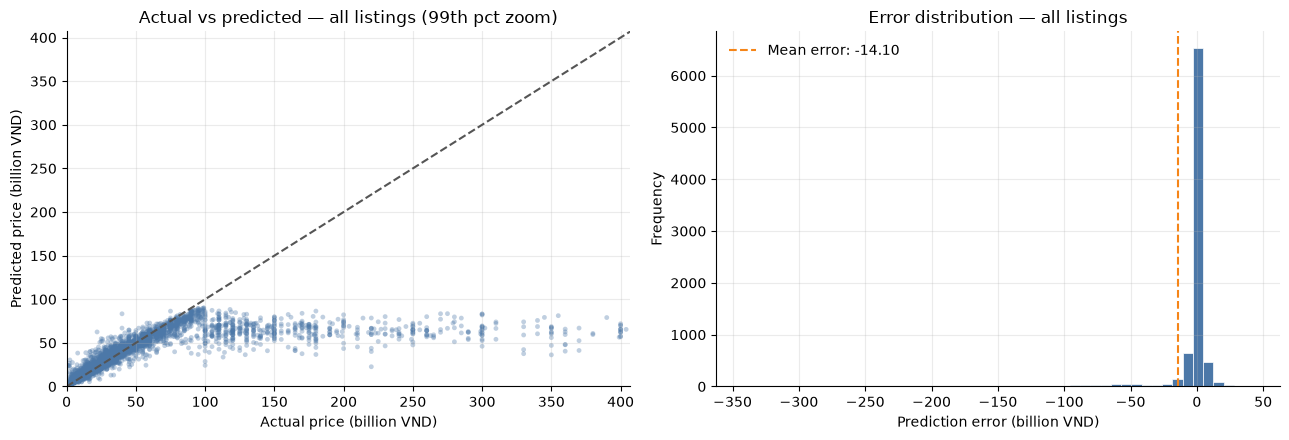

In [17]:
df['error_billion_vnd'] = df['predicted_price_billion_vnd'] - df['price_billion_vnd']

mae_all = df['error_billion_vnd'].abs().mean()
rmse_all = np.sqrt((df['error_billion_vnd'] ** 2).mean())
print("Prediction error on all listings (with known price):")
print(f"  MAE:  {mae_all:.4f} billion VND")
print(f"  RMSE: {rmse_all:.4f} billion VND")
print(f"  Mean error: {df['error_billion_vnd'].mean():.4f} billion VND")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(df['price_billion_vnd'], df['predicted_price_billion_vnd'],
                s=12, alpha=0.35, color='#4C78A8', edgecolors='none')
lims = [0, df['price_billion_vnd'].quantile(0.99)]
axes[0].plot(lims, lims, '--', color='#555555', lw=1.5)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel('Actual price (billion VND)')
axes[0].set_ylabel('Predicted price (billion VND)')
axes[0].set_title('Actual vs predicted — all listings (99th pct zoom)')
axes[0].grid(True, alpha=0.25)
axes[0].spines[['top', 'right']].set_visible(False)

err = df['error_billion_vnd'].dropna()
axes[1].hist(err[err.abs() < err.abs().quantile(0.99)], bins=50,
             color='#4C78A8', edgecolor='white', linewidth=0.5)
axes[1].axvline(err.mean(), color='#F58518', linestyle='--', lw=1.5,
                label=f'Mean error: {err.mean():.2f}')
axes[1].set_xlabel('Prediction error (billion VND)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Error distribution — all listings')
axes[1].legend(frameon=False)
axes[1].grid(True, alpha=0.25)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### 2.4 Lưu kết quả dự đoán

In [18]:
output_file = data_dir / 'predictions_latest.csv'
df.to_csv(output_file, index=False)

print(f"✓ Saved predictions: {output_file}")
print(f"  Records: {len(df)} | Size: {output_file.stat().st_size / 1024 / 1024:.2f} MB")
print("\n✅ Done!")

✓ Saved predictions: data\predictions_latest.csv
  Records: 8581 | Size: 6.52 MB

✅ Done!
